# 🎰 Métodos de Monte Carlo em Aprendizado por Reforço
## Notebook Didático — Duas Aulas Completas

**Disciplina:** Aprendizado por Reforço  
**Referência:** Sutton & Barto (2018), Capítulo 5  
**Ambiente:** Blackjack-v1 (Gymnasium)

---

### 📋 Organização deste notebook

| Aula | Conteúdo | Seção |
|------|----------|-------|
| **Aula 1** | MC Prediction — estimação de $V(s)$ com First-Visit MC | Seções 1 a 5 |
| **Aula 2** | MC Control — ES e On-Policy ε-greedy | Seções 6 a 10 |

### 🎯 O que você vai aprender
- Por que Monte Carlo não precisa de um modelo do ambiente
- Como estimar valores de estados a partir de episódios completos
- Como aprender uma política ótima sem conhecer as regras do ambiente
- Diferenças práticas entre Exploring Starts e ε-greedy
- Como visualizar e interpretar os resultados

---
> 💡 **Como usar este notebook:** Execute cada célula na ordem. Leia os comentários e os textos explicativos antes de olhar o código.


## ⚙️ Configuração do Ambiente

In [1]:
# Instale o Gymnasium caso necessário (descomente a linha abaixo)
!pip install gymnasium
!pip install pandas

import warnings
warnings.filterwarnings('ignore')

import numpy as np
from collections import defaultdict
from typing import Callable, Dict, Tuple, List, Any
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

print("✅ Bibliotecas importadas com sucesso!")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")


  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
Using cached farama_notifications-0.0.6-py3-none-any.whl (2.9 kB)

   -------------------- ------------------- 1/2 [gymnasium]
   -------------------- ------------------- 1/2 [gymnasium]
   ---------------------------------------- 2/2 [gymnasium]

✅ Bibliotecas importadas com sucesso!
   NumPy  : 2.4.6
   Pandas : 3.0.6


In [2]:
# Importação e configuração do Gymnasium (Blackjack)
try:
    import gymnasium as gym
    env_test = gym.make('Blackjack-v1')
    LIBRARY = 'gymnasium'
except ImportError:
    import gym
    env_test = gym.make('Blackjack-v0')
    LIBRARY = 'gym (legado)'

print(f"✅ Usando: {LIBRARY}")
print(f"   Espaço de ações  : {env_test.action_space}")
print(f"   Espaço de estados: {env_test.observation_space}")
print()
print("📌 Estrutura de um estado (player_sum, dealer_card, usable_ace):")
obs, _ = env_test.reset() if LIBRARY == 'gymnasium' else (env_test.reset(), None)
if isinstance(obs, tuple) and len(obs) == 2 and isinstance(obs[1], dict):
    obs = obs[0]
print(f"   Exemplo de estado: player_sum={obs[0]}, dealer_card={obs[1]}, usable_ace={obs[2]}")


✅ Usando: gymnasium
   Espaço de ações  : Discrete(2)
   Espaço de estados: Tuple(Discrete(32), Discrete(11), Discrete(2))

📌 Estrutura de um estado (player_sum, dealer_card, usable_ace):
   Exemplo de estado: player_sum=6, dealer_card=10, usable_ace=0


---
# 🏫 AULA 1 — Monte Carlo Prediction

## 1. Fundamentos Teóricos

### 1.1 Por que Monte Carlo?

Os métodos de **Programação Dinâmica (DP)** exigem o modelo completo do ambiente — a função de transição $p(s', r | s, a)$.  
Na prática, raramente conhecemos esse modelo.

**Monte Carlo resolve isso aprendendo diretamente da experiência:**
> 📌 *"Se você jogar Blackjack mil vezes a partir do mesmo estado, a média das recompensas que recebeu é uma estimativa da qualidade desse estado."*

### 1.2 O Retorno Acumulado

Dado um episódio $S_0, A_0, R_1, S_1, A_1, R_2, \ldots, S_T$, o **retorno** a partir do tempo $t$ é:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{T-t-1} \gamma^k R_{t+k+1}$$

- $\gamma \in [0,1]$ é o **fator de desconto**
- $\gamma = 1$: todas as recompensas futuras valem o mesmo (tarefas episódicas curtas)
- $\gamma \to 0$: o agente valoriza apenas recompensas imediatas

### 1.3 Função de Valor

O objetivo é estimar:
$$V_\pi(s) = \mathbb{E}_\pi[G_t \mid S_t = s]$$

O método Monte Carlo aproxima essa expectativa pela **média amostral** dos retornos observados.

### 1.4 First-Visit vs Every-Visit

| Critério | First-Visit MC | Every-Visit MC |
|----------|---------------|----------------|
| Quais visitas conta? | Só a **primeira** vez que $s$ aparece no episódio | **Toda** visita a $s$ |
| Convergência | Sim (iid → Lei dos Grandes Números) | Sim (convergência quadrática) |
| Viés | Não | Leve viés inicial |
| Uso prático | Mais comum e teoricamente mais limpo | Maior aproveitamento de dados |

> 🎯 **Foco desta aula:** First-Visit MC, que é mais simples de entender e provar.


## 2. O Ambiente Blackjack

### 2.1 Regras Simplificadas

O **Blackjack-v1** do Gymnasium implementa um jogo simplificado:

- O objetivo é chegar o mais perto de **21** sem ultrapassar
- **Ações:** `0 = STICK` (parar), `1 = HIT` (pedir mais carta)
- **Recompensas:** `+1` (vitória), `0` (empate), `-1` (derrota)
- **Estado:** `(player_sum, dealer_card, usable_ace)`
  - `player_sum` ∈ [12, 21]: soma das cartas do jogador
  - `dealer_card` ∈ [1, 10]: carta visível do dealer (Às = 1)
  - `usable_ace` ∈ {True, False}: se o jogador tem um Às contável como 11
- O dealer segue uma **política fixa**: pede carta enquanto soma < 17

### 2.2 Por que Blackjack é ideal para Monte Carlo?

1. **Episódico** — cada jogo termina em poucas rodadas
2. **Sem modelo necessário** — não precisamos calcular probabilidades de cartas
3. **Estado interpretável** — fácil de visualizar e entender
4. **Resultados conhecidos** — podemos comparar com a estratégia básica ótima

### 2.3 Explorando o ambiente


In [3]:
# ============================================================
# Vamos explorar o ambiente Blackjack manualmente
# ============================================================

def explorar_ambiente(n_episodios=5):
    """
    Executa episódios aleatórios e mostra a estrutura dos dados.
    Útil para entender o que o ambiente retorna.
    """
    try:
        import gymnasium as gym
        env = gym.make('Blackjack-v1')
        usa_gymnasium = True
    except ImportError:
        import gym
        env = gym.make('Blackjack-v0')
        usa_gymnasium = False

    print("=" * 60)
    print("🃏 EXPLORANDO O AMBIENTE BLACKJACK")
    print("=" * 60)

    for ep in range(n_episodios):
        print(f"\n📌 Episódio {ep + 1}:")
        print("-" * 40)

        # Reset: inicia um novo jogo
        reset_ret = env.reset()
        state = reset_ret[0] if isinstance(reset_ret, tuple) else reset_ret
        player_sum, dealer_card, usable_ace = state

        print(f"  Estado inicial:")
        print(f"    Soma do jogador : {player_sum}")
        print(f"    Carta do dealer : {dealer_card}")
        print(f"    Tem Ás usável?  : {usable_ace}")

        step = 0
        done = False
        trajectory = []

        while not done:
            # Ação aleatória para exploração
            action = env.action_space.sample()
            action_name = "HIT" if action == 1 else "STICK"

            # Passo no ambiente
            result = env.step(action)
            if len(result) == 5:  # gymnasium
                next_state, reward, terminated, truncated, _ = result
                done = terminated or truncated
            else:  # gym legado
                next_state, reward, done, _ = result

            trajectory.append((state, action_name, reward))
            state = next_state
            step += 1

            if done:
                final_reward = reward
                break

        # Resultado do episódio
        resultado = "✅ VITÓRIA" if final_reward == 1 else ("⚖️ EMPATE" if final_reward == 0 else "❌ DERROTA")
        print(f"  Passos realizados: {step}")
        print(f"  Recompensa final : {final_reward} → {resultado}")

        # Mostra a trajetória
        for t, (s, a, r) in enumerate(trajectory):
            print(f"    t={t}: estado={s}, ação={a}, recompensa={r}")

explorar_ambiente(n_episodios=3)


🃏 EXPLORANDO O AMBIENTE BLACKJACK

📌 Episódio 1:
----------------------------------------
  Estado inicial:
    Soma do jogador : 19
    Carta do dealer : 8
    Tem Ás usável?  : 0
  Passos realizados: 1
  Recompensa final : 1.0 → ✅ VITÓRIA
    t=0: estado=(19, 8, 0), ação=STICK, recompensa=1.0

📌 Episódio 2:
----------------------------------------
  Estado inicial:
    Soma do jogador : 9
    Carta do dealer : 5
    Tem Ás usável?  : 0
  Passos realizados: 2
  Recompensa final : -1.0 → ❌ DERROTA
    t=0: estado=(9, 5, 0), ação=HIT, recompensa=0.0
    t=1: estado=(13, 5, 0), ação=STICK, recompensa=-1.0

📌 Episódio 3:
----------------------------------------
  Estado inicial:
    Soma do jogador : 15
    Carta do dealer : 10
    Tem Ás usável?  : 0
  Passos realizados: 1
  Recompensa final : 1.0 → ✅ VITÓRIA
    t=0: estado=(15, 10, 0), ação=STICK, recompensa=1.0


## 3. Implementação do First-Visit MC Prediction

Agora vamos implementar o algoritmo **passo a passo**.  
Cada função tem comentários detalhados explicando **o quê** e **por quê**.

### 3.1 Pseudocódigo (Sutton & Barto, Cap. 5)

```
ENTRADA: política π (fixa), número de episódios N, fator de desconto γ
INICIALIZAR: V(s) ← 0 para todo s; Returns(s) ← lista vazia

PARA cada episódio i = 1, ..., N:
    Gerar episódio seguindo π: S₀, A₀, R₁, S₁, A₁, R₂, ..., S_T
    G ← 0
    
    PARA t = T-1, T-2, ..., 0:          ← percorre DE TRÁS PRA FRENTE
        G ← γ * G + R_{t+1}             ← acumula o retorno
        
        SE S_t não aparece em S₀,...,S_{t-1}:   ← FIRST-VISIT check
            Returns(S_t).append(G)
            V(S_t) ← média(Returns(S_t))         ← atualiza estimativa
```

> 🔑 **Por que percorrer de trás para frente?**  
> Porque o retorno $G_t = R_{t+1} + \gamma G_{t+1}$. Se conhecemos $G_{t+1}$, calculamos $G_t$ em O(1).  
> Percorrer do fim ao início permite essa recorrência eficiente.


In [4]:
# ============================================================
# BLOCO 1: Tipos de dados (anotações para clareza didática)
# ============================================================

# Um estado do Blackjack é uma tupla de 3 elementos:
#   (soma_jogador: int, carta_dealer: int, tem_as_usavel: bool)
State = Tuple[int, int, bool]

# Uma ação é inteiro: 0 = STICK, 1 = HIT
Action = int

# Uma política é uma função: estado -> ação
Policy = Callable[[State], Action]

# A função de valor mapeia estados para números reais
ValueFunction = Dict[State, float]

print("✅ Tipos definidos:")
print("   State  = Tuple[int, int, bool]")
print("   Action = int  (0=STICK, 1=HIT)")
print("   Policy = Callable[[State], Action]")


✅ Tipos definidos:
   State  = Tuple[int, int, bool]
   Action = int  (0=STICK, 1=HIT)
   Policy = Callable[[State], Action]


In [5]:
# ============================================================
# BLOCO 2: Função generate_episode — gera um episódio completo
# ============================================================

def generate_episode(env, policy: Policy) -> Tuple[List, int]:
    """
    Gera um episódio completo seguindo uma política fixa.

    COMO FUNCIONA:
    1. Reseta o ambiente para obter o estado inicial S₀
    2. Segue a política: A_t = π(S_t)
    3. Executa a ação e registra (S_t, R_t, done, A_t)
    4. Repete até o episódio terminar (done=True)

    COMPATIBILIDADE:
    - Gymnasium: reset() → (obs, info), step() → (obs, r, terminated, truncated, info)
    - Gym legado: reset() → obs, step() → (obs, r, done, info)

    RETORNA:
        trajectory: lista de (state, reward, done, action)
        T         : índice do estado terminal (comprimento - 1)
    """
    trajectory = []
    done = True  # começa True para forçar o reset
    At = None

    while True:
        if done:
            # ── Início de episódio ──────────────────────────────────────
            reset_ret = env.reset()
            # Gymnasium retorna (obs, info); gym legado retorna apenas obs
            if isinstance(reset_ret, tuple) and len(reset_ret) >= 1:
                St = reset_ret[0]
            else:
                St = reset_ret

            Rt = None   # Sem recompensa no passo inicial
            done = False

        else:
            # ── Passo normal ────────────────────────────────────────────
            step_ret = env.step(At)

            if isinstance(step_ret, tuple) and len(step_ret) == 5:
                # Gymnasium: (obs, reward, terminated, truncated, info)
                St, Rt, terminated, truncated, _ = step_ret
                done = bool(terminated or truncated)

            elif isinstance(step_ret, tuple) and len(step_ret) == 4:
                # Gym legado: (obs, reward, done, info)
                St, Rt, done, _ = step_ret

            else:
                St, Rt, done = step_ret[0], step_ret[1], step_ret[2]

        # Escolhe a próxima ação seguindo a política
        At = policy(St)

        # Armazena o passo na trajetória
        trajectory.append((St, Rt, done, At))

        if done:
            break

    # T = índice do último estado (terminal)
    return trajectory, len(trajectory) - 1


# ─── Exemplo de uso ───────────────────────────────────────────────────

def politica_simples(state: State) -> Action:
    """Política naive: STICK se soma >= 20, senão HIT."""
    player_sum, _, _ = state
    return 0 if player_sum >= 20 else 1

try:
    import gymnasium as gym
    env_demo = gym.make('Blackjack-v1')
except:
    import gym
    env_demo = gym.make('Blackjack-v0')

traj, T = generate_episode(env_demo, politica_simples)

print("🎲 Episódio de demonstração:")
print(f"   Comprimento: {len(traj)} passos (T = {T})")
print()
print(f"   {'t':>3}  {'Estado':^30}  {'Ação':^6}  {'Recompensa':>10}")
print("-" * 60)
for t, (s, r, done, a) in enumerate(traj):
    acao = "HIT  " if a == 1 else "STICK"
    recomp = f"{r:+.0f}" if r is not None else "   —"
    print(f"   {t:>3}  {str(s):^30}  {acao:^6}  {recomp:>10}")


🎲 Episódio de demonstração:
   Comprimento: 3 passos (T = 2)

     t              Estado               Ação   Recompensa
------------------------------------------------------------
     0            (9, 7, 0)             HIT              —
     1            (17, 7, 0)            HIT             +0
     2            (23, 7, 0)            STICK           -1


In [6]:
# ============================================================
# BLOCO 3: Algoritmo principal — First-Visit MC Prediction
# ============================================================

def first_visit_MC_prediction(
    env,
    policy: Policy,
    episodes: int = 10_000,
    gamma: float = 1.0,
    verbose: bool = False
) -> ValueFunction:
    """
    ALGORITMO: First-Visit Monte Carlo Prediction

    Estima V_π(s) para uma política fixa π, SEM conhecer o modelo.

    INTUIÇÃO:
    - Executa muitos episódios
    - Para cada estado visitado, calcula o retorno G a partir dali
    - Mantém a MÉDIA dos retornos → isso converge para V_π(s)
    - FIRST-VISIT: conta só a primeira visita ao estado em cada episódio
      (para manter as amostras independentes dentro do episódio)

    PARÂMETROS:
        env      : ambiente Gymnasium/Gym
        policy   : função estado → ação
        episodes : número de episódios de treinamento
        gamma    : fator de desconto [0, 1]
        verbose  : mostra progresso a cada 10%

    RETORNA:
        V : dicionário {estado: valor estimado}
    """

    # Returns[s] = lista de retornos G observados para o estado s
    # defaultdict(list) cria lista vazia automaticamente para novos estados
    Returns = defaultdict(list)

    # V[s] = estimativa atual de V_π(s), atualizada a cada episódio
    V: ValueFunction = {}

    for ep in range(episodes):

        # ── PASSO 1: Gerar episódio completo ────────────────────────
        traj, T = generate_episode(env, policy)

        # ── PASSO 2: Calcular retornos — PERCORRE DE TRÁS PRA FRENTE ─
        G = 0.0  # acumulador do retorno

        for t in range(T - 1, -1, -1):
            # Estado no tempo t
            St, _, _, _ = traj[t]

            # Recompensa recebida APÓS o tempo t (ou seja, em t+1)
            # Nota: traj[t+1][1] = R_{t+1}
            if t + 1 < len(traj):
                _, Rt_1, _, _ = traj[t + 1]
            else:
                Rt_1 = 0  # caso de segurança

            # Recorrência: G_t = γ * G_{t+1} + R_{t+1}
            G = gamma * G + Rt_1

            # ── PASSO 3: Verificação First-Visit ─────────────────────
            # S_t aparece antes no episódio? Se não → PRIMEIRA visita
            estados_anteriores = [traj[i][0] for i in range(0, t)]
            if St not in estados_anteriores:
                # Registro e atualização
                Returns[St].append(G)           # registra o retorno
                V[St] = np.mean(Returns[St])    # atualiza a média

        # Progresso
        if verbose and (ep + 1) % max(1, episodes // 10) == 0:
            print(f"  Episódio {ep+1:>7,d} / {episodes:,} | "
                  f"Estados conhecidos: {len(V):>4}")

    return V


print("✅ Função first_visit_MC_prediction definida!")
print()
print("📌 Resumo do algoritmo:")
print("   1. Gera episódio seguindo π")
print("   2. Percorre de trás para frente calculando G_t = γ*G + R_{t+1}")
print("   3. First-Visit: atualiza só na primeira visita ao estado")
print("   4. V(s) = média de todos os G registrados para s")


✅ Função first_visit_MC_prediction definida!

📌 Resumo do algoritmo:
   1. Gera episódio seguindo π
   2. Percorre de trás para frente calculando G_t = γ*G + R_{t+1}
   3. First-Visit: atualiza só na primeira visita ao estado
   4. V(s) = média de todos os G registrados para s


### 3.2 Políticas de Blackjack

Para avaliar a função de valor, precisamos de uma **política fixa** $\pi$.  
Vamos definir duas políticas com diferentes níveis de sofisticação.


In [15]:
# ============================================================
# BLOCO 4: Políticas de exemplo
# ============================================================

def politica_simples(state: State) -> Action:
    """
    Política determinística básica.
    
    Regra: STICK se soma >= 20, HIT caso contrário.
    
    Interpretação: o jogador é conservador — só para quando
    está quase em 21. Esta é a política do livro Sutton & Barto.
    """
    player_sum, dealer_card, usable_ace = state
    return 0 if player_sum >= 20 else 1  # 0=STICK, 1=HIT


def politica_avancada(state: State) -> Action:
    """
    Política heurística mais sofisticada.

    Considera o ás utilizável (flexibilidade de mão) e a carta do dealer.
    
    Lógica:
    - COM ás usável → mais agressivo (o ás funciona como 'seguro')
    - SEM ás usável → mais conservador (risco de bust maior)
    - Observa a carta do dealer: se dealer está fraco (2-6), podemos
      ser mais conservadores e deixar ele 'estourar'
    """
    player_sum, dealer_card, usable_ace = state

    if usable_ace:
        # Ás usável: podemos ser mais ousados
        if player_sum >= 19:
            return 0  # STICK: 19+ é bom com ás
        elif 17 <= player_sum <= 18:
            # Depende do dealer: se dealer está forte (9+), pedimos mais
            return 0 if dealer_card <= 8 else 1
        else:
            return 1  # HIT: abaixo de 17, sempre pede mais

    else:
        # Sem ás: mais cuidado para não estourar
        if player_sum >= 17:
            return 0  # STICK: 17+ sem ás é arriscado pedir mais
        elif 13 <= player_sum <= 16:
            # Dealer fraco (2-6) → pode estourar → nós ficamos
            return 1 if dealer_card >= 7 else 0
        elif player_sum == 12:
            # Exceção clássica da estratégia básica de blackjack
            return 0 if 4 <= dealer_card <= 6 else 1
        else:
            return 1  # HIT: soma <= 11 nunca estoura


# ─── Teste das políticas ──────────────────────────────────────────────
print("Testando políticas em estados-chave:")
print(f" {'Estado':<35} {'Simples':^10} {'Avançada':^10}")
print("-" * 60)

estados_teste = [
    (12, 10, False),  # soma baixa, dealer forte
    (16, 7,  False),  # clássico dilema
    (20, 6,  False),  # quase 21
    (18, 9,  True),   # soma com ás, dealer forte
    (15, 5,  False),  # dealer fraco → esperar ele estourar
    (13, 4,  False),  # dealer muito fraco
]

for estado in estados_teste:
    p_simp = "STICK" if politica_simples(estado) == 0 else "HIT  "
    p_avan = "STICK" if politica_avancada(estado) == 0 else "HIT  "
    igual = "✓" if p_simp == p_avan else "≠"
    print(f"  (soma={estado[0]:>2}, dealer={estado[1]:>2}, as={str(estado[2]):<5}) "
          f"  {p_simp:^10} {p_avan:^10}  {igual}")


Testando políticas em estados-chave:
 Estado                               Simples    Avançada 
------------------------------------------------------------
  (soma=12, dealer=10, as=False)     HIT        HIT       ✓
  (soma=16, dealer= 7, as=False)     HIT        HIT       ✓
  (soma=20, dealer= 6, as=False)     STICK      STICK     ✓
  (soma=18, dealer= 9, as=True )     HIT        HIT       ✓
  (soma=15, dealer= 5, as=False)     HIT        STICK     ≠
  (soma=13, dealer= 4, as=False)     HIT        STICK     ≠


## 4. Executando o Algoritmo e Visualizando os Resultados


In [16]:
# ============================================================
# BLOCO 5: Funções de visualização — Heatmap de V(s)
# ============================================================

def valor_para_matriz(V: ValueFunction, usable_ace: bool) -> np.ndarray:
    """
    Converte o dicionário V(s) em uma matriz 10x10 para plotagem.
    
    Eixos:
    - Linhas  : soma do jogador (12 a 21) → 10 valores
    - Colunas : carta do dealer  (1 a 10) → 10 valores
    - Filtro  : usable_ace = True ou False
    """
    Vd = defaultdict(float, V)
    matriz = np.zeros((10, 10))

    for player_sum in range(12, 22):    # linhas: soma 12..21
        for dealer_card in range(1, 11):  # colunas: dealer 1..10
            i = player_sum - 12   # índice da linha (0..9)
            j = dealer_card - 1   # índice da coluna (0..9)
            matriz[i, j] = Vd[(player_sum, dealer_card, usable_ace)]

    return matriz


def plot_valor_heatmap(V: ValueFunction,
                       titulo: str = "",
                       mostrar_valores: bool = False):
    """
    Plota heatmaps de V(s) para os dois casos de ás (usável / não usável).

    INTERPRETAÇÃO DO GRÁFICO:
    - Cores quentes (amarelo/verde) → valores altos → boa posição para o jogador
    - Cores frias (roxo/azul escuro) → valores baixos → posição desfavorável
    - Eixo X: carta visível do dealer (Às=1, 2, ..., 10)
    - Eixo Y: soma do jogador (12 a 21)
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(titulo, fontsize=14, fontweight='bold', y=1.01)

    for ax, usa_as in zip(axes, [True, False]):
        dados = valor_para_matriz(V, usa_as)

        im = ax.imshow(
            dados,
            cmap='viridis',
            origin='lower',
            extent=[0.5, 10.5, 11.5, 21.5],  # limites dos eixos
            aspect='auto',
            vmin=-1, vmax=1
        )

        titulo_sub = f"Com Ás usável" if usa_as else "Sem Ás usável"
        ax.set_title(titulo_sub, fontsize=12, pad=10)
        ax.set_xlabel('Carta visível do dealer', fontsize=10)
        ax.set_ylabel('Soma do jogador', fontsize=10)
        ax.set_xticks(range(1, 11))
        ax.set_xticklabels(['A' if x == 1 else str(x) for x in range(1, 11)])
        ax.set_yticks(range(12, 22))

        if mostrar_valores:
            for i in range(10):
                for j in range(10):
                    val = dados[i, j]
                    cor = 'white' if val < 0 else 'black'
                    ax.text(j + 1, i + 12, f'{val:.2f}',
                            ha='center', va='center',
                            fontsize=6.5, color=cor, fontweight='bold')

        plt.colorbar(im, ax=ax, label='V(s)')

    plt.tight_layout()
    plt.show()


print("✅ Funções de visualização definidas!")


✅ Funções de visualização definidas!


In [17]:
# ============================================================
# BLOCO 6: TREINAMENTO — First-Visit MC Prediction
# (Esta célula pode levar ~30 segundos para 50.000 episódios)
# ============================================================

try:
    import gymnasium as gym
    env = gym.make('Blackjack-v1')
except:
    import gym
    env = gym.make('Blackjack-v0')

# ── Parâmetros ─────────────────────────────────────────────
GAMMA    = 1.0     # desconto = 1 (sem desconto) — blackjack é episódico curto
EPISODIOS = 50_000  # número de jogos simulados

print("📊 Estimando V(s) com First-Visit MC Prediction")
print(f"   Política  : simples (STICK se soma ≥ 20)")
print(f"   Episódios : {EPISODIOS:,}")
print(f"   Gamma (γ) : {GAMMA}")
print()

# ── Treino com política simples ─────────────────────────────
print("Rodando com a política simples...")
V_simples = first_visit_MC_prediction(
    env,
    politica_simples,
    episodes=EPISODIOS,
    gamma=GAMMA,
    verbose=True
)

print()
print(f"✅ Estimativa concluída!")
print(f"   Estados visitados: {len(V_simples):,}")
print(f"   Valor médio de V(s): {np.mean(list(V_simples.values())):.4f}")


📊 Estimando V(s) com First-Visit MC Prediction
   Política  : simples (STICK se soma ≥ 20)
   Episódios : 50,000
   Gamma (γ) : 1.0

Rodando com a política simples...
  Episódio   5,000 / 50,000 | Estados conhecidos:  279
  Episódio  10,000 / 50,000 | Estados conhecidos:  280
  Episódio  15,000 / 50,000 | Estados conhecidos:  280
  Episódio  20,000 / 50,000 | Estados conhecidos:  280
  Episódio  25,000 / 50,000 | Estados conhecidos:  280
  Episódio  30,000 / 50,000 | Estados conhecidos:  280
  Episódio  35,000 / 50,000 | Estados conhecidos:  280
  Episódio  40,000 / 50,000 | Estados conhecidos:  280
  Episódio  45,000 / 50,000 | Estados conhecidos:  280
  Episódio  50,000 / 50,000 | Estados conhecidos:  280

✅ Estimativa concluída!
   Estados visitados: 280
   Valor médio de V(s): -0.3025


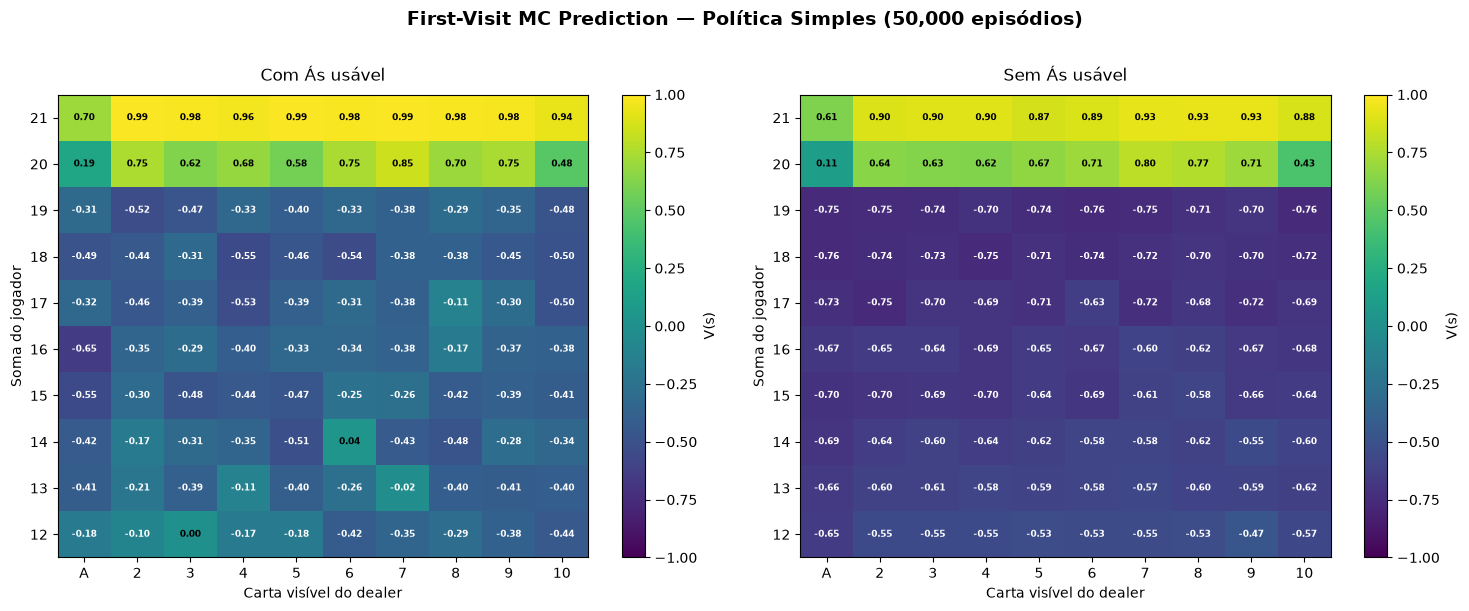


📌 INTERPRETAÇÃO DO HEATMAP:
   - Soma 20-21: valores POSITIVOS (esperamos ganhar com mão forte)
   - Soma 12-16: valores NEGATIVOS (posição difícil, risco de bust)
   - Dealer mostrando 1 (Às): valores mais negativos (dealer forte)
   - Sem Ás: heatmap mais uniforme que Com Ás (menos flexibilidade)


In [18]:
# Visualização dos resultados — Política simples
plot_valor_heatmap(
    V_simples,
    titulo=f"First-Visit MC Prediction — Política Simples ({EPISODIOS:,} episódios)",
    mostrar_valores=True
)

print()
print("📌 INTERPRETAÇÃO DO HEATMAP:")
print("   - Soma 20-21: valores POSITIVOS (esperamos ganhar com mão forte)")
print("   - Soma 12-16: valores NEGATIVOS (posição difícil, risco de bust)")
print("   - Dealer mostrando 1 (Às): valores mais negativos (dealer forte)")
print("   - Sem Ás: heatmap mais uniforme que Com Ás (menos flexibilidade)")


Rodando com a política avançada...
  Episódio   5,000 / 50,000 | Estados conhecidos:  279
  Episódio  10,000 / 50,000 | Estados conhecidos:  280
  Episódio  15,000 / 50,000 | Estados conhecidos:  280
  Episódio  20,000 / 50,000 | Estados conhecidos:  280
  Episódio  25,000 / 50,000 | Estados conhecidos:  280
  Episódio  30,000 / 50,000 | Estados conhecidos:  280
  Episódio  35,000 / 50,000 | Estados conhecidos:  280
  Episódio  40,000 / 50,000 | Estados conhecidos:  280
  Episódio  45,000 / 50,000 | Estados conhecidos:  280
  Episódio  50,000 / 50,000 | Estados conhecidos:  280


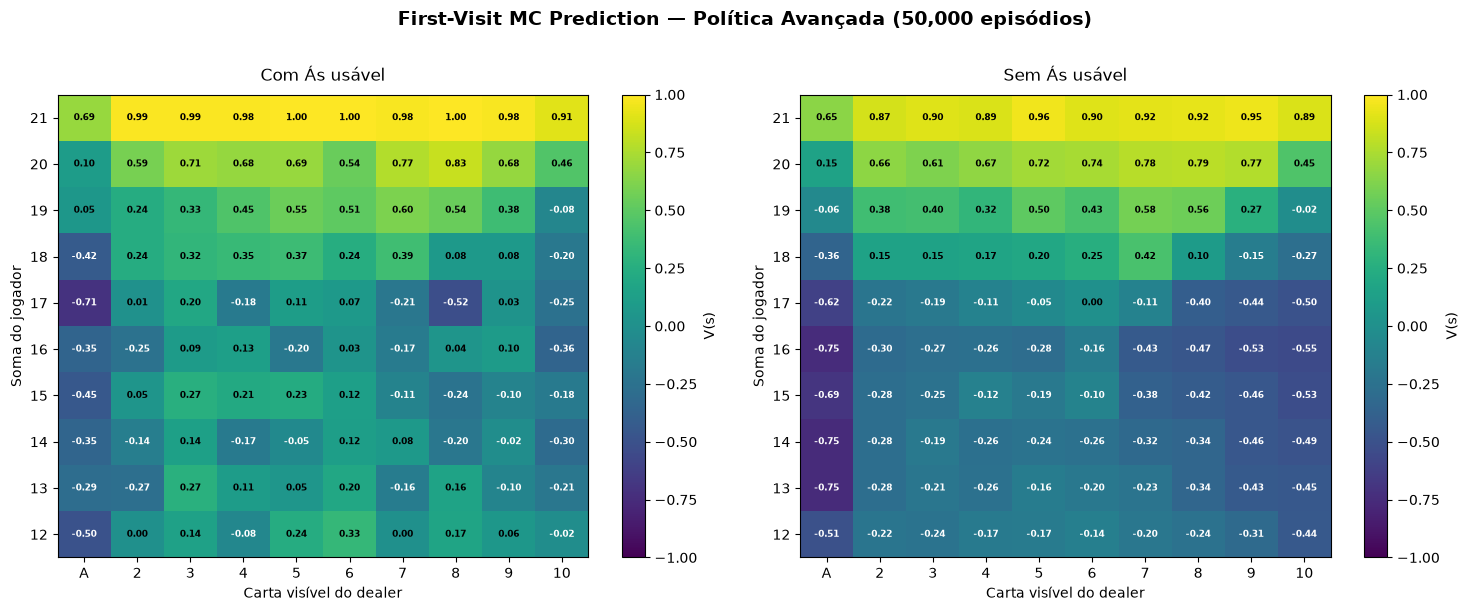


📊 COMPARAÇÃO ENTRE POLÍTICAS:
   Métrica                      Simples   Avançada
--------------------------------------------------
   Valor médio de V(s)          -0.3025     0.0460
   Valor mínimo                 -0.7607    -0.7527
   Valor máximo                  0.9877     1.0000


In [19]:
# ── Comparação: política avançada ──────────────────────────────────
print("Rodando com a política avançada...")
V_avancada = first_visit_MC_prediction(
    env,
    politica_avancada,
    episodes=EPISODIOS,
    gamma=GAMMA,
    verbose=True
)

plot_valor_heatmap(
    V_avancada,
    titulo=f"First-Visit MC Prediction — Política Avançada ({EPISODIOS:,} episódios)",
    mostrar_valores=True
)

# Comparação numérica
v_simples_vals = np.array(list(V_simples.values()))
v_avancada_vals = np.array(list(V_avancada.values()))

print()
print("📊 COMPARAÇÃO ENTRE POLÍTICAS:")
print(f"   {'Métrica':<25} {'Simples':>10} {'Avançada':>10}")
print("-" * 50)
print(f"   {'Valor médio de V(s)':<25} {np.mean(v_simples_vals):>10.4f} {np.mean(v_avancada_vals):>10.4f}")
print(f"   {'Valor mínimo':<25} {np.min(v_simples_vals):>10.4f} {np.min(v_avancada_vals):>10.4f}")
print(f"   {'Valor máximo':<25} {np.max(v_simples_vals):>10.4f} {np.max(v_avancada_vals):>10.4f}")


## 5. Análise de Convergência

Como sabemos que o algoritmo está convergindo?  
Monitoramos o **valor médio de V(s)** ao longo dos episódios.  
Se a curva se estabiliza, o algoritmo convergiu.


📈 Analisando convergência (30.000 episódios)...


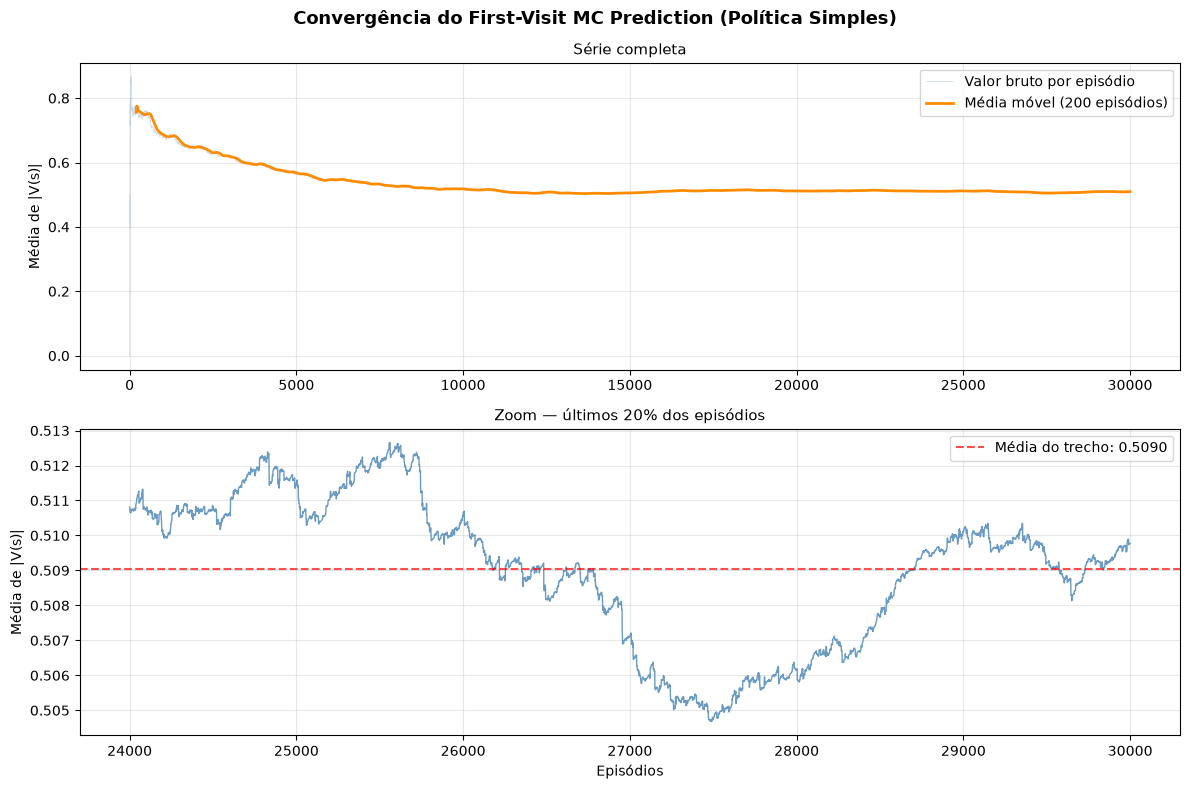


📌 INTERPRETAÇÃO:
   - A curva deve subir rápido no início (novos estados sendo descobertos)
   - Depois estabiliza (médias convergindo para V_π verdadeiro)
   - Oscilações residuais = variância amostral (esperada em MC)


In [20]:
# ============================================================
# BLOCO 7: Curva de convergência — monitora o algoritmo
# ============================================================

def calcular_convergencia(env, policy: Policy,
                           episodes: int = 30_000,
                           gamma: float = 1.0,
                           janela: int = 200):
    """
    Roda o First-Visit MC Prediction e registra a evolução de V(s)
    episódio a episódio, para análise de convergência.
    
    RETORNA:
        V          : função de valor final
        historico  : lista com o valor médio |V(s)| a cada episódio
    """
    Returns = defaultdict(list)
    V = {}
    historico = []

    for ep in range(episodes):
        traj, T = generate_episode(env, policy)
        G = 0.0

        for t in range(T - 1, -1, -1):
            St, _, _, _ = traj[t]
            _, Rt_1, _, _ = traj[t + 1] if t + 1 < len(traj) else (None, 0, None, None)
            G = gamma * G + Rt_1

            if St not in [traj[i][0] for i in range(0, t)]:
                Returns[St].append(G)
                V[St] = np.mean(Returns[St])

        # Métrica de convergência: valor médio absoluto dos estados conhecidos
        if V:
            historico.append(np.mean(np.abs(list(V.values()))))
        else:
            historico.append(0.0)

    return V, historico


def plot_convergencia(historico: List[float],
                      titulo: str = "Convergência",
                      janela: int = 200):
    """
    Plota dois gráficos:
    1. Curva completa com média móvel
    2. Zoom nos últimos 20% (para ver se estabilizou)
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    fig.suptitle(titulo, fontsize=13, fontweight='bold')

    # ── Gráfico 1: série completa ─────────────────────────────────
    ax1.plot(historico, alpha=0.25, linewidth=0.6,
             color='steelblue', label='Valor bruto por episódio')

    if len(historico) > janela:
        media_movel = np.convolve(
            historico, np.ones(janela) / janela, mode='valid'
        )
        ax1.plot(range(janela - 1, len(historico)), media_movel,
                 linewidth=2, color='darkorange',
                 label=f'Média móvel ({janela} episódios)')

    ax1.set_ylabel('Média de |V(s)|', fontsize=10)
    ax1.set_title('Série completa', fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # ── Gráfico 2: zoom nos últimos 20% ───────────────────────────
    inicio = max(0, int(len(historico) * 0.8))
    ax2.plot(range(inicio, len(historico)),
             historico[inicio:],
             linewidth=1, alpha=0.8, color='steelblue')
    ax2.axhline(y=np.mean(historico[inicio:]),
                color='red', linestyle='--', alpha=0.7,
                label=f'Média do trecho: {np.mean(historico[inicio:]):.4f}')
    ax2.set_xlabel('Episódios', fontsize=10)
    ax2.set_ylabel('Média de |V(s)|', fontsize=10)
    ax2.set_title('Zoom — últimos 20% dos episódios', fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()


# ── Executar análise de convergência ────────────────────────────────
print("📈 Analisando convergência (30.000 episódios)...")
V_conv, historico = calcular_convergencia(env, politica_simples, episodes=30_000)

plot_convergencia(
    historico,
    titulo="Convergência do First-Visit MC Prediction (Política Simples)"
)

print()
print("📌 INTERPRETAÇÃO:")
print("   - A curva deve subir rápido no início (novos estados sendo descobertos)")
print("   - Depois estabiliza (médias convergindo para V_π verdadeiro)")
print("   - Oscilações residuais = variância amostral (esperada em MC)")


## ✏️ Exercícios — Aula 1

### Exercício 1: Every-Visit MC

Modifique a função `first_visit_MC_prediction` para implementar o **every-visit MC**  
(remova o filtro de primeira visita e atualize V(s) em toda visita ao estado).  
Compare os resultados com o first-visit para 10.000 e 50.000 episódios.

### Exercício 2: Efeito do Fator de Desconto

Execute o algoritmo com `gamma = 0.9` e compare com `gamma = 1.0`.  
Qual o impacto nos valores estimados? Por que para blackjack `gamma=1.0` é mais natural?

### Exercício 3: Análise de um Estado Específico

Escolha um estado (ex: `(16, 10, False)`) e trace como a estimativa de V(s)  
evolui ao longo dos episódios. Quando ela se estabiliza?

```python
# Dica de implementação do exercício 3:
# Modifique calcular_convergencia para registrar V de um estado específico
estado_alvo = (16, 10, False)
historico_estado = []
# ... dentro do loop: historico_estado.append(V.get(estado_alvo, 0.0))
```


---
# 🏫 AULA 2 — Monte Carlo Control

## 6. Da Predição ao Controle

Na Aula 1, estimamos $V_\pi(s)$ para uma **política fixa** $\pi$.  
Agora queremos **melhorar a política** — aprender a política **ótima** $\pi^*$.

### 6.1 Generalised Policy Iteration (GPI)

A ideia fundamental do controle em RL:

```
loop:
    Avaliação:  estima Q_π(s,a) para a política atual π
    Melhoria:   torna π greedy em relação a Q_π
```

Para aplicar GPI com Monte Carlo, estimamos $Q_\pi(s,a)$ em vez de $V_\pi(s)$:

$$Q_\pi(s,a) = \mathbb{E}_\pi[G_t \mid S_t = s, A_t = a]$$

### 6.2 O Problema da Exploração

**Problema:** se $\pi$ é determinística (greedy), muitos pares $(s,a)$ nunca são visitados.  
Sem visitas → sem estimativas de $Q$ → sem melhoria de política.

**Duas soluções:**

| Abordagem | Solução | Aula |
|-----------|---------|------|
| **Exploring Starts (ES)** | Inicia episódios em $(s,a)$ aleatórios | Seção 7 |
| **ε-greedy (On-Policy)** | Com prob. ε, escolhe ação aleatória | Seção 8 |


## 7. Monte Carlo ES (Exploring Starts)

### 7.1 Ideia

Em vez de uma política exploratória, garantimos exploração no **início do episódio**:
- Escolhemos $(S_0, A_0)$ **aleatoriamente** de todo o espaço válido
- Isso garante que todo par $(s,a)$ seja visitado eventualmente

### 7.2 Pseudocódigo (Sutton & Barto, Cap. 5.3)

```
INICIALIZAR: Q(s,a) ← 0; Returns(s,a) ← lista vazia; π ← política arbitrária

PARA cada episódio:
    Amostrar (S₀, A₀) uniformemente de todos os pares válidos   ← EXPLORING STARTS
    Gerar episódio de (S₀, A₀) seguindo π (A₀ é fixado no t=0)
    
    G ← 0
    PARA t = T-1, ..., 0:
        G ← γ * G + R_{t+1}
        SE (S_t, A_t) é PRIMEIRA VISITA no episódio:
            Returns(S_t, A_t).append(G)
            Q(S_t, A_t) ← média(Returns(S_t, A_t))
            π(S_t) ← argmax_a Q(S_t, a)    ← melhoria greedy
```

> ⚠️ **Limitação prática:** exploring starts exige controlar o estado inicial do ambiente.  
> Em aplicações reais (ex: robótica), isso raramente é possível.  
> No Blackjack simulado, podemos "forçar" qualquer estado inicial.


In [21]:
# ============================================================
# BLOCO 8: Wrapper BlackjackES — suporte a Exploring Starts
# ============================================================

class BlackjackES:
    """
    Wrapper em torno do ambiente Blackjack que permite iniciar
    episódios em qualquer estado (s, a) — necessário para ES.

    PROBLEMA original: o Gymnasium não permite forçar um estado inicial.
    SOLUÇÃO: manipulamos diretamente o estado interno do ambiente.

    Atributos:
        _env      : ambiente Blackjack original
        nb_actions: número de ações disponíveis (2: STICK, HIT)
    """

    def __init__(self):
        try:
            import gymnasium as gym
            self._env = gym.make('Blackjack-v1')
        except ImportError:
            import gym
            self._env = gym.make('Blackjack-v0')

        self.nb_actions = 2  # 0=STICK, 1=HIT

    def amostrar_estado_acao(self) -> Tuple[Tuple[int, int, bool], int]:
        """
        Amostra um par (estado, ação) aleatório — o coração do ES.

        Estado = (player_sum, dealer_card, has_ace)
        Ação   = 0 (STICK) ou 1 (HIT)

        IMPORTANTE: amostrar uniformemente garante que todo par
        (s, a) seja visitado com probabilidade positiva.
        """
        player_sum  = np.random.randint(12, 22)      # 12 a 21
        dealer_card = np.random.randint(1, 11)       # 1 a 10
        has_ace     = bool(np.random.randint(0, 2))  # True ou False
        state       = (player_sum, dealer_card, has_ace)
        action      = int(np.random.randint(0, 2))   # 0 ou 1
        return state, action

    def _soma_mao(self, mao: List[int]) -> int:
        """Soma simples das cartas."""
        return sum(mao)

    def _tem_as_usavel(self, mao: List[int]) -> bool:
        """Verifica se há um ás que pode valer 11 sem estourar."""
        return 1 in mao and sum(mao) + 10 <= 21

    def reset_es(self, estado_inicial: Tuple[int, int, bool]):
        """
        FORÇA o ambiente a iniciar em um estado específico.

        Isso é o que diferencia ES dos métodos normais:
        não dependemos do reset aleatório padrão.

        COMO FUNCIONA:
        1. Chama reset() normal para inicializar estruturas internas
        2. Substitui as cartas do dealer e do jogador manualmente
        3. Recalcula a observação a partir do novo estado
        """
        player_sum, dealer_card, has_ace = estado_inicial
        base = self._env.unwrapped

        # Reset padrão primeiro (necessário para inicializar estruturas)
        self._env.reset()

        # ── Configura cartas do dealer ────────────────────────────────
        # dealer_shows: carta visível; dealer_hides: carta oculta (aleatória)
        dealer_hides = np.random.choice([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10])
        base.dealer = [dealer_card, dealer_hides]

        # ── Configura cartas do jogador ───────────────────────────────
        if has_ace:
            # Ás (1) + outra carta para atingir player_sum - 11
            base.player = [player_sum - 11, 1]
        else:
            # Sem ás: usamos 10 + resto
            if player_sum == 21:
                base.player = [10, 9, 2]   # caso especial
            else:
                base.player = [player_sum - 10, 10]

        # ── Reconstrói a observação ───────────────────────────────────
        soma = self._soma_mao(base.player)
        tem_as = self._tem_as_usavel(base.player)
        if tem_as:
            soma += 10
        obs = (soma, base.dealer[0], tem_as)
        return obs

    def step(self, action: int):
        """Delega o passo para o ambiente original."""
        return self._env.step(action)


# ─── Teste do BlackjackES ─────────────────────────────────────────────
env_es = BlackjackES()

print("🎲 Testando o BlackjackES (Exploring Starts):")
print()

for _ in range(5):
    estado, acao = env_es.amostrar_estado_acao()
    obs_inicial = env_es.reset_es(estado)
    print(f"  Estado solicitado: {estado} | Ação: {'HIT  ' if acao == 1 else 'STICK'}")
    print(f"  Obs. retornada   : {obs_inicial}")
    print()


🎲 Testando o BlackjackES (Exploring Starts):

  Estado solicitado: (15, 7, False) | Ação: HIT  
  Obs. retornada   : (15, 7, False)

  Estado solicitado: (21, 6, False) | Ação: STICK
  Obs. retornada   : (21, 6, False)

  Estado solicitado: (14, 3, False) | Ação: HIT  
  Obs. retornada   : (14, 3, False)

  Estado solicitado: (21, 7, False) | Ação: HIT  
  Obs. retornada   : (21, 7, False)

  Estado solicitado: (21, 4, False) | Ação: HIT  
  Obs. retornada   : (21, 4, False)



In [22]:
# ============================================================
# BLOCO 9: Geração de episódio com Exploring Starts
# ============================================================

def gerar_episodio_ES(env_es: BlackjackES,
                      politica: Dict[State, Action],
                      S0: Tuple[int, int, bool],
                      A0: int) -> Tuple[List, int]:
    """
    Gera um episódio começando EXATAMENTE em (S0, A0).

    A0 é executado como PRIMEIRA AÇÃO (não escolhido pela política).
    A partir do segundo passo, a política π decide as ações.

    PARÂMETROS:
        env_es  : ambiente BlackjackES
        politica: dicionário estado → ação (política aprendida)
        S0      : estado inicial forçado
        A0      : ação inicial forçada
    """
    trajectory = []
    done = True
    At = None

    while True:
        if done:
            # Forçamos o estado inicial para o Exploring Start
            St = env_es.reset_es(S0)
            Rt = None
            done = False
            At = A0  # ← primeira ação é FORÇADA (ES)

        else:
            result = env_es.step(At)
            if len(result) == 5:  # gymnasium
                St, Rt, terminated, truncated, _ = result
                done = bool(terminated or truncated)
            else:  # gym legado
                St, Rt, done, _ = result

            # A partir do segundo passo, segue a política aprendida
            At = politica.get(St, 0)   # default: STICK para estados não vistos

        trajectory.append((St, Rt, done, At))

        if done:
            break

    return trajectory, len(trajectory) - 1


print("✅ Função gerar_episodio_ES definida!")


✅ Função gerar_episodio_ES definida!


In [23]:
# ============================================================
# BLOCO 10: Algoritmo Monte Carlo ES Control
# ============================================================

def monte_carlo_ES_control(
    env_es: BlackjackES,
    episodes: int = 100_000,
    gamma: float = 1.0,
    verbose: bool = False
) -> Tuple[Dict, Dict]:
    """
    ALGORITMO: Monte Carlo ES (Exploring Starts) Control

    Aprende Q(s,a) e uma política ótima π* usando ES para garantir
    que todo par (s,a) seja explorado.

    DIFERENÇA FUNDAMENTAL vs Prediction:
    - Antes: estimávamos V(s) para política FIXA
    - Agora: estimamos Q(s,a) E MELHORAMOS π simultaneamente

    IMPLEMENTAÇÃO EFICIENTE:
    Em vez de guardar TODAS as listas de retornos (custo de memória alto),
    mantemos apenas:
    - Returns_sum[s,a] = soma de todos os retornos vistos
    - Counts[s,a]      = número de visitas
    - Q[s,a]           = Returns_sum / Counts  (média incremental)

    PARÂMETROS:
        env_es  : ambiente BlackjackES
        episodes: número de episódios
        gamma   : fator de desconto
        verbose : exibe progresso

    RETORNA:
        Q : função ação-valor estimada {(estado, ação): valor}
        pi: política greedy derivada de Q  {estado: ação}
    """

    Q = defaultdict(float)          # Q[(s,a)] = estimativa de Q_π(s,a)
    Returns_sum = defaultdict(float)  # soma acumulada dos retornos
    Counts = defaultdict(int)         # contador de visitas
    pi: Dict[State, Action] = defaultdict(int)  # política (default: STICK)

    for ep in range(episodes):

        # ── PASSO 1: Exploring Start — escolha aleatória de (S0, A0) ─
        S0, A0 = env_es.amostrar_estado_acao()

        # ── PASSO 2: Gerar episódio a partir de (S0, A0) ─────────────
        traj, T = gerar_episodio_ES(env_es, pi, S0, A0)

        # ── PASSO 3: Calcular retornos e atualizar Q ─────────────────
        G = 0.0
        visitados = set()  # rastreia pares (s,a) já vistos neste episódio

        for t in range(T - 1, -1, -1):
            St, _, _, At = traj[t]
            _, Rt_1, _, _ = traj[t + 1] if t + 1 < len(traj) else (None, 0, None, None)

            # Retorno acumulado
            G = gamma * G + Rt_1

            sa = (St, At)

            # ── First-Visit check ────────────────────────────────────
            if sa not in visitados:
                visitados.add(sa)

                # Atualização incremental da média
                Counts[sa] += 1
                Returns_sum[sa] += G
                Q[sa] = Returns_sum[sa] / Counts[sa]

                # ── MELHORIA DE POLÍTICA (greedy) ────────────────────
                # Para o estado St, escolhe a ação que maximiza Q
                q_vals = [Q.get((St, a), 0.0) for a in range(env_es.nb_actions)]
                max_q = max(q_vals)
                # Tie-breaking aleatório: se há empate, escolhe aleatoriamente
                melhores_acoes = [i for i, q in enumerate(q_vals) if q == max_q]
                pi[St] = int(np.random.choice(melhores_acoes))

        # Progresso
        if verbose and (ep + 1) % max(1, episodes // 10) == 0:
            n_estados = len(set(s for (s, a) in Q.keys()))
            print(f"  Episódio {ep+1:>8,d} / {episodes:,} | "
                  f"Pares (s,a) visitados: {len(Q):>5} | "
                  f"Estados únicos: {n_estados:>4}")

    return Q, pi


print("✅ Função monte_carlo_ES_control definida!")
print()
print("📌 Resumo do algoritmo MC ES:")
print("   1. Amostrar (S0, A0) aleatoriamente  ← Exploring Starts")
print("   2. Gerar episódio forçando S0, A0")
print("   3. Calcular G_t de trás para frente")
print("   4. Para cada (s,a) — primeira visita:")
print("      a) Atualizar Q(s,a) = média dos retornos")
print("      b) Melhorar π(s) = argmax_a Q(s,a)")


✅ Função monte_carlo_ES_control definida!

📌 Resumo do algoritmo MC ES:
   1. Amostrar (S0, A0) aleatoriamente  ← Exploring Starts
   2. Gerar episódio forçando S0, A0
   3. Calcular G_t de trás para frente
   4. Para cada (s,a) — primeira visita:
      a) Atualizar Q(s,a) = média dos retornos
      b) Melhorar π(s) = argmax_a Q(s,a)


In [24]:
# ============================================================
# BLOCO 11: Executar MC ES Control
# ============================================================

env_es = BlackjackES()

EPISODIOS_ES = 200_000  # ES precisa de mais episódios pois começa aleatório
GAMMA_ES     = 1.0

print("🎲 Executando Monte Carlo ES Control...")
print(f"   Episódios: {EPISODIOS_ES:,}")
print(f"   Gamma (γ): {GAMMA_ES}")
print()

Q_es, pi_es = monte_carlo_ES_control(
    env_es,
    episodes=EPISODIOS_ES,
    gamma=GAMMA_ES,
    verbose=True
)

print()
print(f"✅ Treinamento concluído!")
print(f"   Pares (s,a) com estimativas : {len(Q_es):,}")
print(f"   Estados únicos cobertos     : {len(set(s for (s,a) in Q_es)):,}")


🎲 Executando Monte Carlo ES Control...
   Episódios: 200,000
   Gamma (γ): 1.0

  Episódio   20,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio   40,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio   60,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio   80,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  100,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  120,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  140,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  160,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  180,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200
  Episódio  200,000 / 200,000 | Pares (s,a) visitados:   400 | Estados únicos:  200

✅ Treinamento concluído!
   Pares (s,a) com estimativas : 400
   Estados únicos

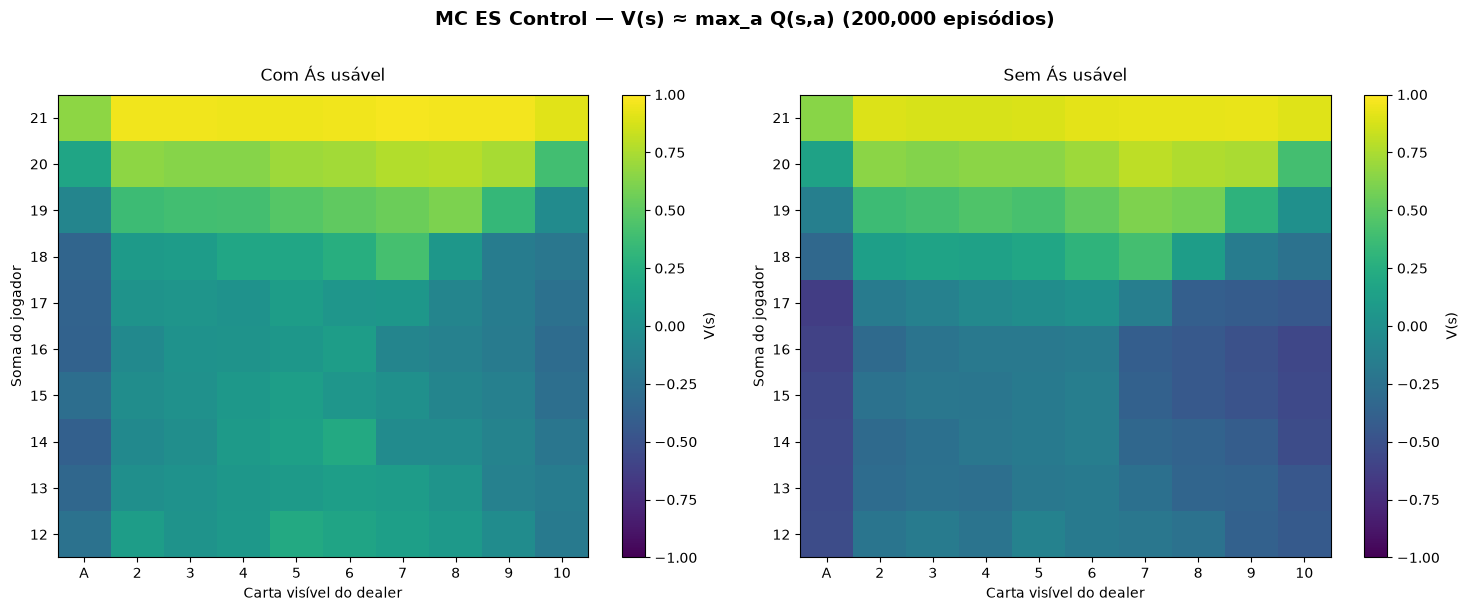

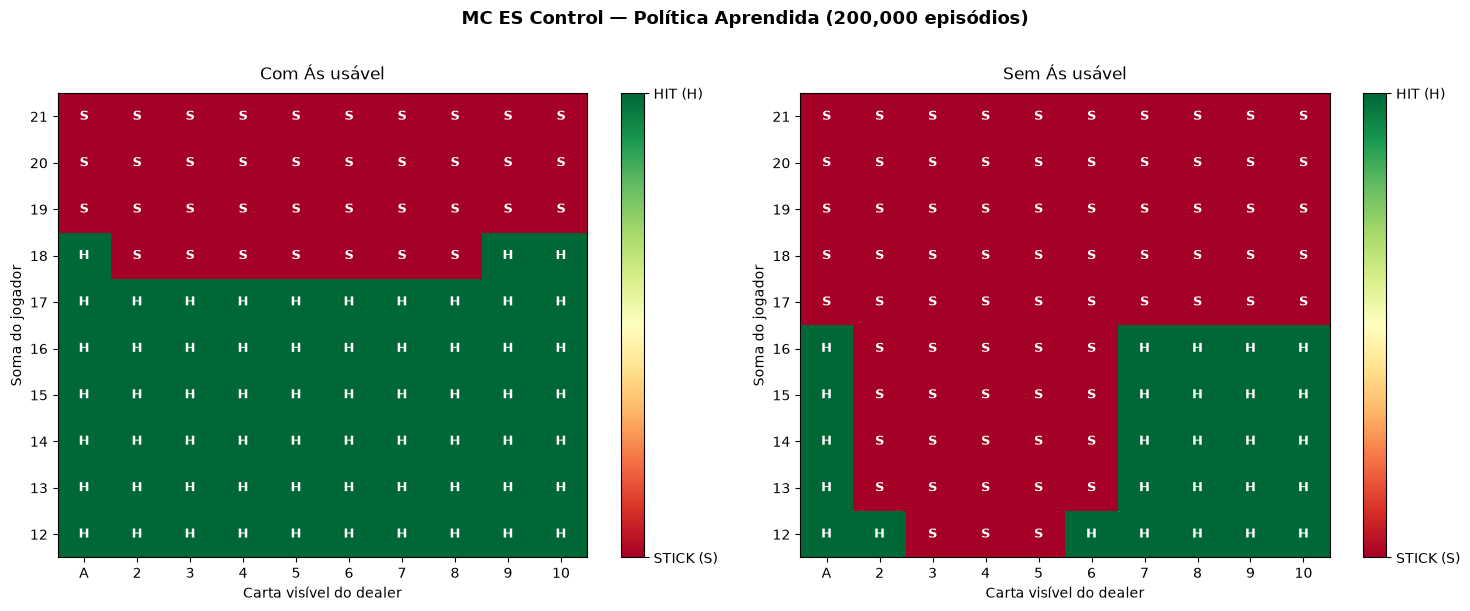


📌 INTERPRETAÇÃO DO MAPA DE POLÍTICA:
   - Verde (H): o algoritmo aprendeu que HIT é melhor neste estado
   - Vermelho (S): o algoritmo aprendeu que STICK é melhor
   - Com Ás usável: padrão HIT mais agressivo (ás = seguro)
   - Sem Ás usável: região STICK começa mais cedo (risco de bust)
   - Compare com a estratégia básica de blackjack!


In [25]:
# ============================================================
# BLOCO 12: Visualização dos resultados MC ES
# ============================================================

def q_para_v(Q: Dict) -> Dict:
    """V(s) ≈ max_a Q(s,a) — valor do melhor par ação para cada estado."""
    V = {}
    for (s, a), q in Q.items():
        V[s] = max(V.get(s, -np.inf), q)
    return V


def plot_politica_heatmap(pi: Dict, titulo: str = 'Política Aprendida',
                          mostrar_acoes: bool = True):
    """
    Visualiza a política aprendida π(s):
    - Verde: HIT (pede carta)
    - Vermelho: STICK (para)
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(titulo, fontsize=13, fontweight='bold', y=1.01)

    for ax, usa_as in zip(axes, [True, False]):
        arr = np.zeros((10, 10))
        for ps in range(12, 22):
            for dc in range(1, 11):
                arr[ps - 12, dc - 1] = pi.get((ps, dc, usa_as), 0)

        im = ax.imshow(arr, origin='lower', extent=[0.5, 10.5, 11.5, 21.5],
                       aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
        titulo_sub = "Com Ás usável" if usa_as else "Sem Ás usável"
        ax.set_title(titulo_sub, fontsize=12, pad=10)
        ax.set_xlabel('Carta visível do dealer', fontsize=10)
        ax.set_ylabel('Soma do jogador', fontsize=10)
        ax.set_xticks(range(1, 11))
        ax.set_xticklabels(['A' if x == 1 else str(x) for x in range(1, 11)])
        ax.set_yticks(range(12, 22))

        if mostrar_acoes:
            for i in range(10):
                for j in range(10):
                    texto = "H" if arr[i, j] == 1 else "S"
                    cor = 'white'
                    ax.text(j + 1, i + 12, texto, ha='center', va='center',
                            fontsize=9, fontweight='bold', color=cor)

        cbar = fig.colorbar(im, ax=ax)
        cbar.set_ticks([0, 1])
        cbar.set_ticklabels(['STICK (S)', 'HIT (H)'])

    plt.tight_layout()
    plt.show()


# V(s) a partir de Q
V_es = q_para_v(Q_es)

# Heatmap de V(s) aproximado
plot_valor_heatmap(
    V_es,
    titulo=f"MC ES Control — V(s) ≈ max_a Q(s,a) ({EPISODIOS_ES:,} episódios)",
    mostrar_valores=False
)

# Heatmap da política aprendida
plot_politica_heatmap(
    pi_es,
    titulo=f"MC ES Control — Política Aprendida ({EPISODIOS_ES:,} episódios)",
    mostrar_acoes=True
)

print()
print("📌 INTERPRETAÇÃO DO MAPA DE POLÍTICA:")
print("   - Verde (H): o algoritmo aprendeu que HIT é melhor neste estado")
print("   - Vermelho (S): o algoritmo aprendeu que STICK é melhor")
print("   - Com Ás usável: padrão HIT mais agressivo (ás = seguro)")
print("   - Sem Ás usável: região STICK começa mais cedo (risco de bust)")
print("   - Compare com a estratégia básica de blackjack!")


## 8. On-Policy MC Control com ε-greedy

### 8.1 Motivação

O ES resolve o problema de exploração de forma **forçada** (estado inicial aleatório).  
O **On-Policy** usa uma solução mais natural: a **política ε-greedy**.

### 8.2 Política ε-greedy

$$\pi(a|s) = \begin{cases}
1 - \varepsilon + \dfrac{\varepsilon}{|\mathcal{A}(s)|} & \text{se } a = \arg\max_a Q(s,a) \quad \text{(exploração)}\\
\dfrac{\varepsilon}{|\mathcal{A}(s)|} & \text{caso contrário} \quad \text{(ação aleatória)}
\end{cases}$$

- Com probabilidade $1-\varepsilon$: age de forma **greedy** (exploração)
- Com probabilidade $\varepsilon$: age **aleatoriamente** (exploração)

### 8.3 Vantagens sobre ES

| Critério | Exploring Starts | ε-greedy On-Policy |
|----------|-----------------|-------------------|
| Requer controle do estado inicial | ✅ Sim | ❌ Não |
| Funciona em ambientes reais | ❌ Raramente | ✅ Sim |
| Exploração garantida | ✅ (com prob. > 0) | ✅ (com ε > 0) |
| Política final | Determinística | ε-greedy (soft) |

> 📌 **Tradeoff da exploração:**  
> Um $\varepsilon$ grande explora mais mas converge para política pior.  
> Um $\varepsilon$ pequeno explora pouco mas pode convergir mais rápido.  
> Solução clássica: **decaimento de ε** ao longo do treinamento.


In [26]:
# ============================================================
# BLOCO 13: Política ε-greedy
# ============================================================

def argmax_aleatorio(valores: List[float]) -> int:
    """
    Argmax com quebra de empates aleatória.
    
    Por que isso importa?
    No início, Q(s,a) = 0 para todos os pares (s,a).
    Se usarmos argmax normal, sempre escolhemos a mesma ação (índice 0).
    Com quebra aleatória, exploramos equitativamente no início.
    """
    arr = np.array(valores)
    melhores = np.flatnonzero(arr == arr.max())  # todos os índices com valor máximo
    return int(np.random.choice(melhores))       # escolhe aleatoriamente entre empatados


def epsilon_greedy(Q: Dict, estado: State, n_acoes: int, eps: float) -> Action:
    """
    Seleciona uma ação ε-greedy baseada em Q.
    
    FUNCIONAMENTO:
    1. Gera número aleatório u ~ Uniform(0, 1)
    2. Se u > eps → escolhe a MELHOR ação segundo Q (greedy)
    3. Se u <= eps → escolhe ação ALEATÓRIA (exploração)
    
    PARÂMETROS:
        Q       : função ação-valor atual
        estado  : estado atual
        n_acoes : número de ações disponíveis
        eps     : taxa de exploração (0 = greedy puro; 1 = aleatório puro)
    """
    # Q-valores para cada ação no estado atual
    q_vals = [Q.get((estado, a), 0.0) for a in range(n_acoes)]

    # Melhor ação atual (com tie-breaking aleatório)
    melhor_acao = argmax_aleatorio(q_vals)

    # Decisão: explorar ou explotar?
    if np.random.rand() > eps:
        return melhor_acao   # EXPLORAR a melhor ação conhecida
    else:
        return np.random.choice(n_acoes)  # EXPLORAÇÃO: ação aleatória


# ─── Demonstração do comportamento ε-greedy ──────────────────────────
print("🎯 Demonstração da política ε-greedy:")
print()

# Simula escolhas com diferentes valores de ε
Q_demo = {((16, 10, False), 0): -0.5, ((16, 10, False), 1): -0.3}
estado_demo = (16, 10, False)

for eps in [0.0, 0.1, 0.3, 1.0]:
    contagem = {0: 0, 1: 0}
    for _ in range(10_000):
        a = epsilon_greedy(Q_demo, estado_demo, n_acoes=2, eps=eps)
        contagem[a] += 1
    print(f"  ε={eps:.1f}: STICK={contagem[0]/100:.1f}%  HIT={contagem[1]/100:.1f}%"
          f"  (melhor ação: HIT pois Q=-0.3 > Q=-0.5)")
print()
print("   ε=0.0 → 100% greedy (sempre HIT)")
print("   ε=0.1 → 90% greedy + 10% aleatório")
print("   ε=1.0 → 100% aleatório (50/50)")


🎯 Demonstração da política ε-greedy:

  ε=0.0: STICK=0.0%  HIT=100.0%  (melhor ação: HIT pois Q=-0.3 > Q=-0.5)
  ε=0.1: STICK=5.0%  HIT=95.0%  (melhor ação: HIT pois Q=-0.3 > Q=-0.5)
  ε=0.3: STICK=14.7%  HIT=85.3%  (melhor ação: HIT pois Q=-0.3 > Q=-0.5)
  ε=1.0: STICK=49.3%  HIT=50.7%  (melhor ação: HIT pois Q=-0.3 > Q=-0.5)

   ε=0.0 → 100% greedy (sempre HIT)
   ε=0.1 → 90% greedy + 10% aleatório
   ε=1.0 → 100% aleatório (50/50)


In [27]:
# ============================================================
# BLOCO 14: Geração de episódio On-Policy
# ============================================================

def gerar_episodio_on_policy(env, Q: Dict, eps: float, n_acoes: int) -> Tuple[List, int]:
    """
    Gera um episódio usando a política ε-greedy atual.

    DIFERENÇA vs ES:
    - ES: começa em (S0, A0) forçado; política fixa após isso
    - On-Policy: começa normalmente; TODA ação é ε-greedy

    Isso é mais realista: o agente nunca 'manipula' o ambiente.
    """
    trajectory = []
    done = True
    At = None

    while True:
        if done:
            reset_ret = env.reset()
            St = reset_ret[0] if isinstance(reset_ret, tuple) else reset_ret
            Rt = None
            done = False
        else:
            result = env.step(At)
            if len(result) == 5:
                St, Rt, terminated, truncated, _ = result
                done = bool(terminated or truncated)
            else:
                St, Rt, done, _ = result

        # ← ação sempre ε-greedy (não forçada)
        At = epsilon_greedy(Q, St, n_acoes, eps)
        trajectory.append((St, Rt, done, At))

        if done:
            break

    return trajectory, len(trajectory) - 1


print("✅ Função gerar_episodio_on_policy definida!")


✅ Função gerar_episodio_on_policy definida!


In [28]:
# ============================================================
# BLOCO 15: Algoritmo On-Policy First-Visit MC Control
# ============================================================

def on_policy_first_visit_MC_control(
    env,
    episodes: int = 100_000,
    gamma: float = 1.0,
    eps: float = 0.1,
    verbose: bool = False
) -> Tuple[Dict, List[float]]:
    """
    ALGORITMO: On-Policy First-Visit Monte Carlo Control

    Aprende Q(s,a) usando episódios gerados pela política ε-greedy.
    Mais prático que ES porque não precisa de estado inicial controlado.

    IMPLEMENTAÇÃO:
    - Usa soma + contador em vez de listas (eficiente em memória)
    - Q[s,a] = Returns_sum[s,a] / Counts[s,a]  (média incremental)
    - Política é sempre ε-greedy sobre Q atual
    - Registra histórico de convergência para análise

    PARÂMETROS:
        env      : ambiente Gymnasium/Gym
        episodes : número de episódios
        gamma    : fator de desconto
        eps      : epsilon para ε-greedy
        verbose  : exibe progresso

    RETORNA:
        Q       : função ação-valor estimada
        historico: lista com métrica de convergência por episódio
    """

    Q = defaultdict(float)
    Returns_sum = defaultdict(float)
    Counts = defaultdict(int)

    # Número de ações do ambiente
    try:
        n_acoes = env.action_space.n
    except Exception:
        n_acoes = 2

    historico = []  # para monitorar convergência

    for ep in range(episodes):

        # ── PASSO 1: Gerar episódio com política ε-greedy atual ───────
        traj, T = gerar_episodio_on_policy(env, Q, eps, n_acoes)

        G = 0.0
        visitados_ep = set()  # pares (s,a) vistos neste episódio

        # ── PASSO 2: Calcular retornos e atualizar Q ──────────────────
        for t in range(T - 1, -1, -1):
            St, _, _, At = traj[t]
            _, Rt_1, _, _ = traj[t + 1] if t + 1 < len(traj) else (None, 0, None, None)

            G = gamma * G + Rt_1

            sa = (St, At)

            if sa not in visitados_ep:
                visitados_ep.add(sa)

                # Atualização incremental: evita guardar lista de retornos
                Counts[sa] += 1
                Returns_sum[sa] += G
                Q[sa] = Returns_sum[sa] / Counts[sa]
                # Nota: a melhoria de política é IMPLÍCITA —
                # a ação escolhida na próxima chamada a epsilon_greedy
                # já usará o Q atualizado

        # Métrica de convergência: max Q por estado
        if Q:
            estado_maxq = {}
            for (s, a), q in Q.items():
                estado_maxq[s] = max(estado_maxq.get(s, -np.inf), q)
            historico.append(np.mean(list(estado_maxq.values())))
        else:
            historico.append(0.0)

        if verbose and (ep + 1) % max(1, episodes // 10) == 0:
            print(f"  Episódio {ep+1:>8,d} / {episodes:,} | "
                  f"Pares (s,a): {len(Q):>5} | "
                  f"Avg max Q: {historico[-1]:.4f}")

    return Q, historico


def derivar_politica_greedy(Q: Dict, n_acoes: int = 2) -> Dict:
    """Extrai a política greedy (determinística) a partir de Q."""
    politica = {}
    estados_acoes = defaultdict(dict)

    for (s, a), q in Q.items():
        estados_acoes[s][a] = q

    for s, acoes in estados_acoes.items():
        q_vals = [acoes.get(a, -np.inf) for a in range(n_acoes)]
        politica[s] = argmax_aleatorio(q_vals)

    return politica


print("✅ Algoritmo On-Policy MC Control definido!")


✅ Algoritmo On-Policy MC Control definido!


In [31]:
# ============================================================
# BLOCO 16: Executar e visualizar On-Policy MC Control
# ============================================================

try:
    import gymnasium as gym
    env = gym.make('Blackjack-v1')
except:
    import gym
    env = gym.make('Blackjack-v0')

EPISODIOS_OP = 200_000
GAMMA_OP     = 1.0
EPSILON      = 0.4

print("🎲 Executando On-Policy First-Visit MC Control...")
print(f"   Episódios : {EPISODIOS_OP:,}")
print(f"   Gamma (γ) : {GAMMA_OP}")
print(f"   Epsilon (ε): {EPSILON}")
print()

Q_op, historico_op = on_policy_first_visit_MC_control(
    env,
    episodes=EPISODIOS_OP,
    gamma=GAMMA_OP,
    eps=EPSILON,
    verbose=True
)

# Derivar política greedy final
pi_op = derivar_politica_greedy(Q_op, n_acoes=2)

print()
print(f"✅ Treinamento concluído!")
print(f"   Pares (s,a): {len(Q_op):,}")
print(f"   Estados únicos: {len(pi_op):,}")


🎲 Executando On-Policy First-Visit MC Control...
   Episódios : 200,000
   Gamma (γ) : 1.0
   Epsilon (ε): 0.4

  Episódio   20,000 / 200,000 | Pares (s,a):   558 | Avg max Q: -0.0046
  Episódio   40,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0103
  Episódio   60,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0069
  Episódio   80,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0064
  Episódio  100,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0079
  Episódio  120,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0115
  Episódio  140,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0108
  Episódio  160,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0119
  Episódio  180,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0124
  Episódio  200,000 / 200,000 | Pares (s,a):   560 | Avg max Q: -0.0092

✅ Treinamento concluído!
   Pares (s,a): 560
   Estados únicos: 280


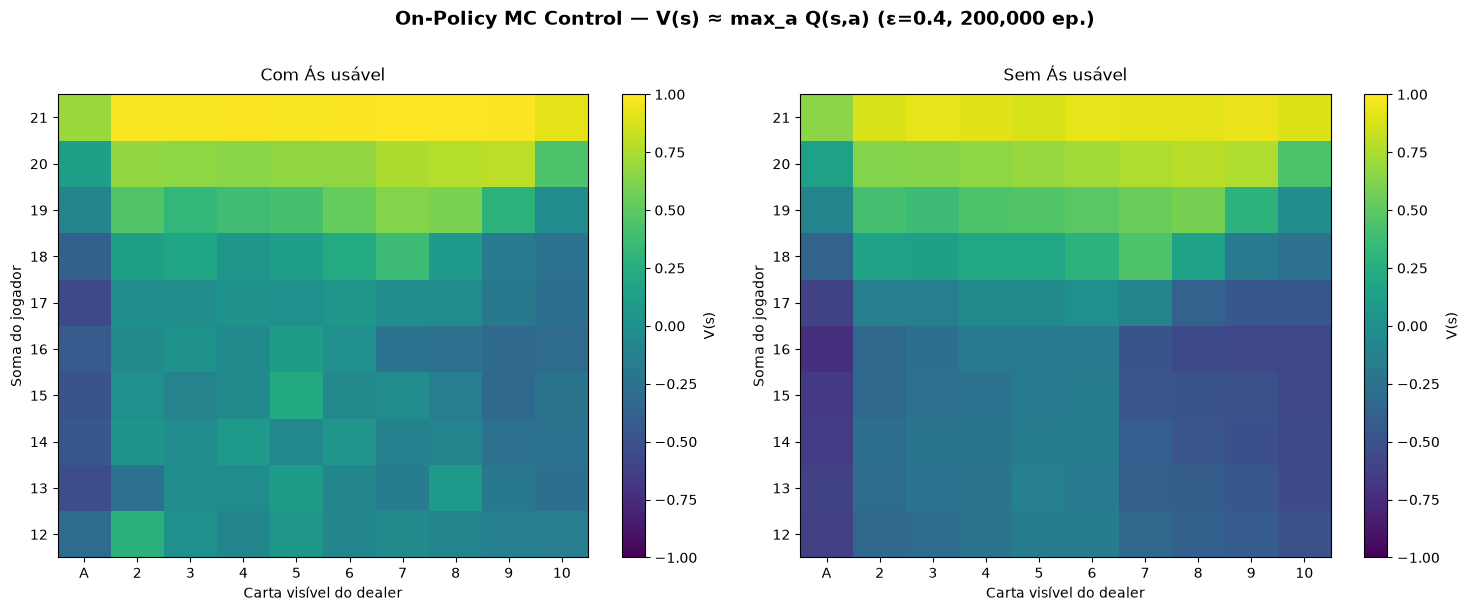

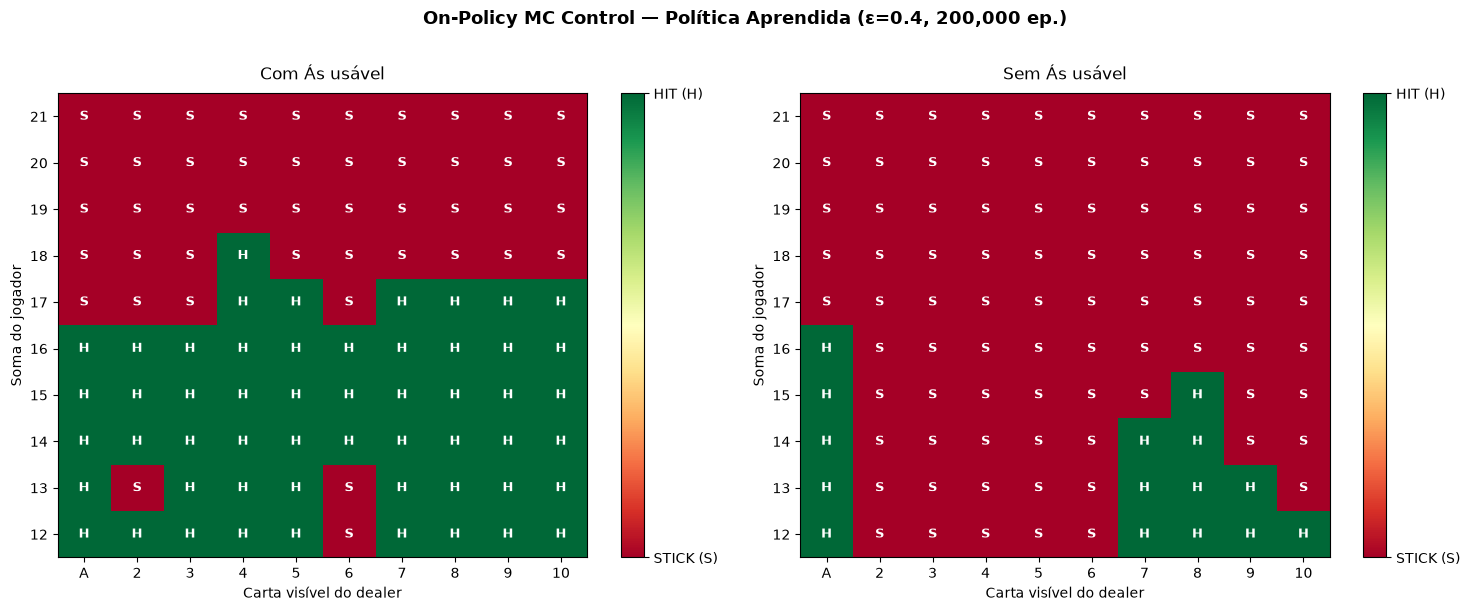

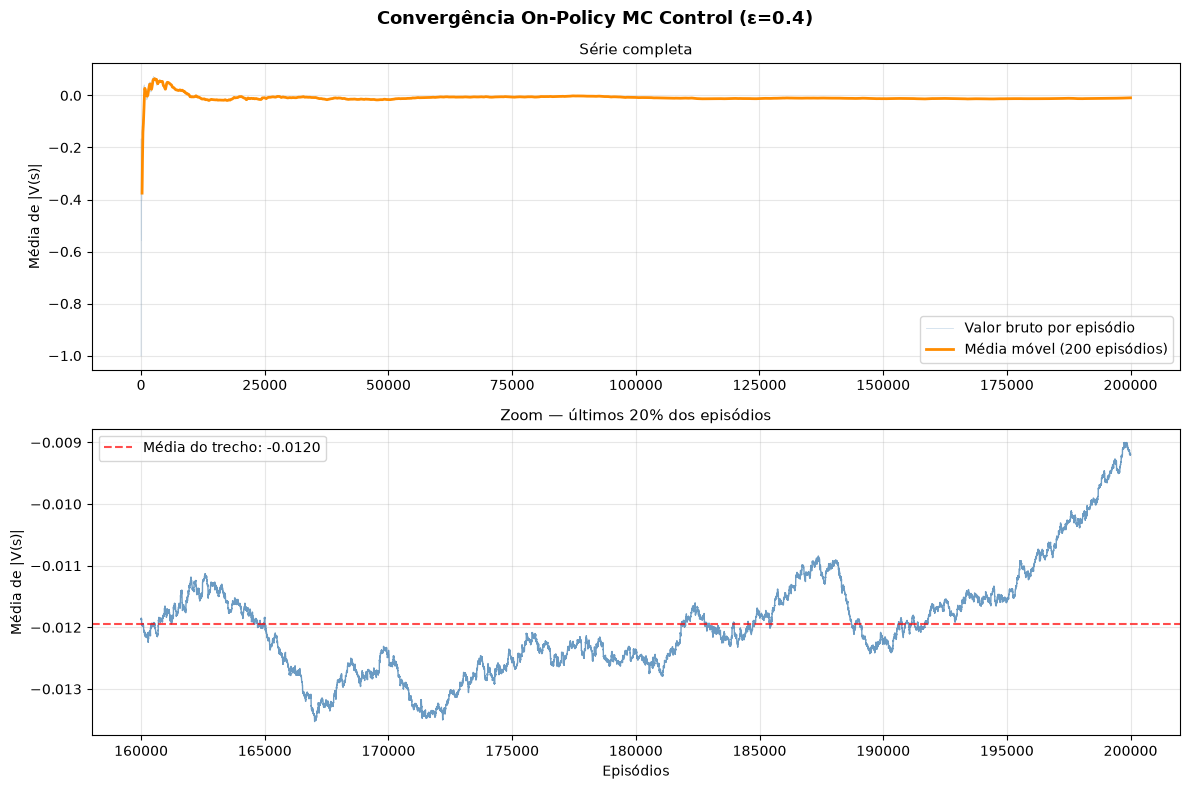

In [32]:
# Visualização dos resultados On-Policy
V_op = q_para_v(Q_op)

plot_valor_heatmap(
    V_op,
    titulo=f"On-Policy MC Control — V(s) ≈ max_a Q(s,a) "
           f"(ε={EPSILON}, {EPISODIOS_OP:,} ep.)",
    mostrar_valores=False
)

plot_politica_heatmap(
    pi_op,
    titulo=f"On-Policy MC Control — Política Aprendida "
           f"(ε={EPSILON}, {EPISODIOS_OP:,} ep.)"
)

# Convergência
plot_convergencia(
    historico_op,
    titulo=f"Convergência On-Policy MC Control (ε={EPSILON})"
)


## 9. Comparação entre os Três Métodos


📊 Avaliando políticas em 50,000 jogos...

  Método                            Vitória     Empate    Derrota
  Política Simples (heurística)       29.5%       4.3%      66.2%
  MC ES Control                       39.6%       7.3%      53.1%
  On-Policy MC Control (ε-greedy)      43.3%       7.9%      48.8%


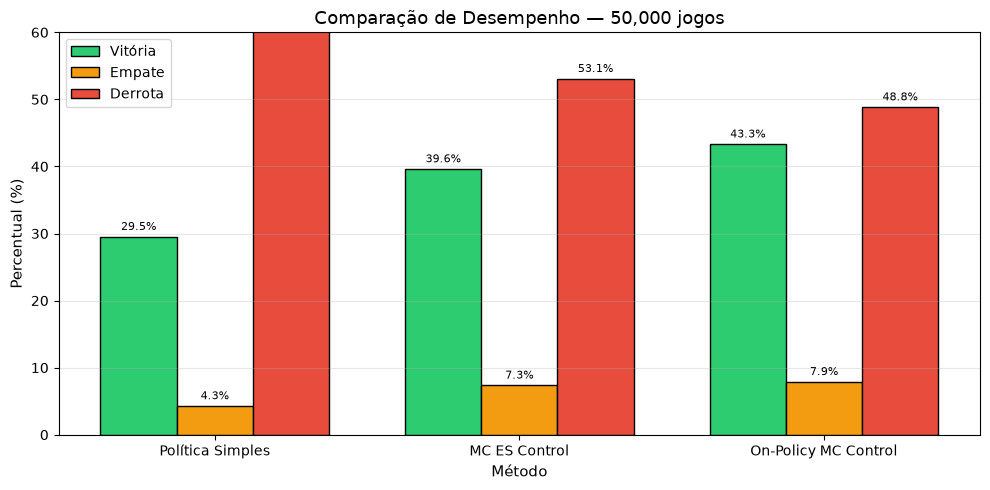

In [33]:
# ============================================================
# BLOCO 17: Comparação entre os três algoritmos
# ============================================================

def calcular_taxa_vitorias(env, politica: Dict, n_jogos: int = 10_000) -> Dict:
    """
    Avalia a política aprendida simulando n jogos.
    Retorna o percentual de vitórias, empates e derrotas.
    """
    resultados = {'vitoria': 0, 'empate': 0, 'derrota': 0}

    for _ in range(n_jogos):
        reset_ret = env.reset()
        state = reset_ret[0] if isinstance(reset_ret, tuple) else reset_ret
        done = False

        while not done:
            action = politica.get(state, 0)  # default: STICK
            result = env.step(action)
            if len(result) == 5:
                state, reward, terminated, truncated, _ = result
                done = terminated or truncated
            else:
                state, reward, done, _ = result

        if reward > 0:
            resultados['vitoria'] += 1
        elif reward == 0:
            resultados['empate'] += 1
        else:
            resultados['derrota'] += 1

    total = n_jogos
    return {k: v / total * 100 for k, v in resultados.items()}


# ── Avaliar as três políticas ──────────────────────────────────────────
N_JOGOS = 50_000

print(f"📊 Avaliando políticas em {N_JOGOS:,} jogos...")
print()

# Política simples (heurística, sem aprendizado)
res_simples = calcular_taxa_vitorias(env, {s: politica_simples(s) for s in
    [(ps, dc, ace)
     for ps in range(12, 22)
     for dc in range(1, 11)
     for ace in [True, False]]}, N_JOGOS)

# MC ES
res_es = calcular_taxa_vitorias(env, pi_es, N_JOGOS)

# On-Policy MC
res_op = calcular_taxa_vitorias(env, pi_op, N_JOGOS)

# ── Tabela de resultados ──────────────────────────────────────────────
print("=" * 65)
print(f"  {'Método':<30} {'Vitória':>10} {'Empate':>10} {'Derrota':>10}")
print("=" * 65)
print(f"  {'Política Simples (heurística)':<30} "
      f"{res_simples['vitoria']:>9.1f}% "
      f"{res_simples['empate']:>9.1f}% "
      f"{res_simples['derrota']:>9.1f}%")
print(f"  {'MC ES Control':<30} "
      f"{res_es['vitoria']:>9.1f}% "
      f"{res_es['empate']:>9.1f}% "
      f"{res_es['derrota']:>9.1f}%")
print(f"  {'On-Policy MC Control (ε-greedy)':<30} "
      f"{res_op['vitoria']:>9.1f}% "
      f"{res_op['empate']:>9.1f}% "
      f"{res_op['derrota']:>9.1f}%")
print("=" * 65)

# ── Gráfico de barras ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

metodos = ['Política Simples', 'MC ES Control', 'On-Policy MC Control']
vitorias = [res_simples['vitoria'], res_es['vitoria'], res_op['vitoria']]
derrotas = [res_simples['derrota'], res_es['derrota'], res_op['derrota']]
empates  = [res_simples['empate'],  res_es['empate'],  res_op['empate']]

x = np.arange(len(metodos))
w = 0.25

bars1 = ax.bar(x - w,     vitorias, w, label='Vitória',  color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x,         empates,  w, label='Empate',   color='#f39c12', edgecolor='black')
bars3 = ax.bar(x + w,     derrotas, w, label='Derrota',  color='#e74c3c', edgecolor='black')

ax.set_xlabel('Método', fontsize=11)
ax.set_ylabel('Percentual (%)', fontsize=11)
ax.set_title(f'Comparação de Desempenho — {N_JOGOS:,} jogos', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metodos)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0, 60)

# Valores nas barras
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()


## 10. Efeito do Hiperparâmetro ε

⚙️ Testando diferentes valores de ε...
   (Cada rodada usa 50.000 episódios de treinamento)

  ε=0.01 → Vitória: 40.5%  Empate: 7.7%  Derrota: 51.8%
  ε=0.05 → Vitória: 41.9%  Empate: 8.4%  Derrota: 49.7%
  ε=0.10 → Vitória: 42.3%  Empate: 7.8%  Derrota: 49.9%
  ε=0.20 → Vitória: 43.0%  Empate: 8.0%  Derrota: 48.9%
  ε=0.50 → Vitória: 42.2%  Empate: 7.7%  Derrota: 50.1%


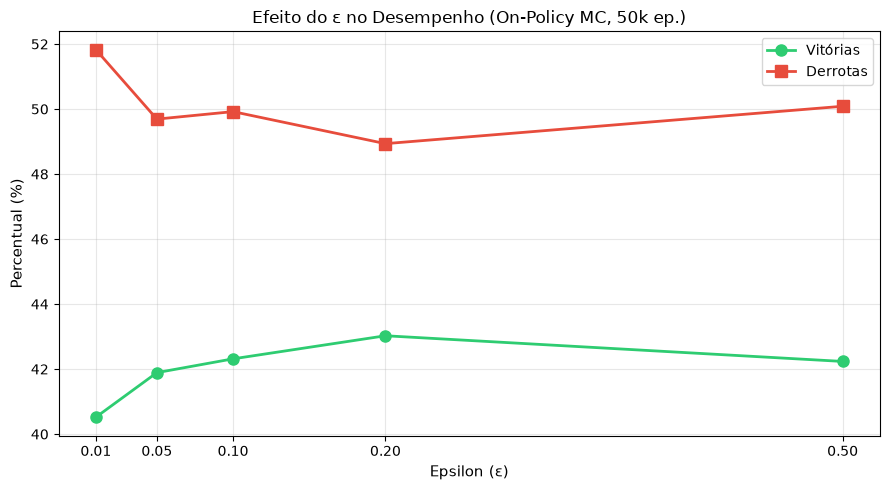


📌 INTERPRETAÇÃO:
   - ε muito pequeno (0.01): pouca exploração → converge lento
   - ε muito grande (0.5): muito aleatório → política ruim
   - ε ≈ 0.1: bom equilíbrio exploração-exploração para este problema


In [34]:
# ============================================================
# BLOCO 18: Efeito do epsilon no desempenho
# ============================================================

print("⚙️ Testando diferentes valores de ε...")
print("   (Cada rodada usa 50.000 episódios de treinamento)")
print()

epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]
resultados_eps = {}

for eps in epsilons:
    Q_tmp, _ = on_policy_first_visit_MC_control(
        env, episodes=50_000, gamma=1.0, eps=eps, verbose=False
    )
    pi_tmp = derivar_politica_greedy(Q_tmp)
    res = calcular_taxa_vitorias(env, pi_tmp, n_jogos=20_000)
    resultados_eps[eps] = res
    print(f"  ε={eps:.2f} → Vitória: {res['vitoria']:.1f}%  "
          f"Empate: {res['empate']:.1f}%  "
          f"Derrota: {res['derrota']:.1f}%")

# Gráfico
fig, ax = plt.subplots(figsize=(9, 5))

eps_vals = list(resultados_eps.keys())
vit_vals = [resultados_eps[e]['vitoria'] for e in eps_vals]
der_vals = [resultados_eps[e]['derrota'] for e in eps_vals]

ax.plot(eps_vals, vit_vals, 'o-', color='#2ecc71', linewidth=2,
        markersize=8, label='Vitórias')
ax.plot(eps_vals, der_vals, 's-', color='#e74c3c', linewidth=2,
        markersize=8, label='Derrotas')
ax.set_xlabel('Epsilon (ε)', fontsize=11)
ax.set_ylabel('Percentual (%)', fontsize=11)
ax.set_title('Efeito do ε no Desempenho (On-Policy MC, 50k ep.)', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(eps_vals)

plt.tight_layout()
plt.show()

print()
print("📌 INTERPRETAÇÃO:")
print("   - ε muito pequeno (0.01): pouca exploração → converge lento")
print("   - ε muito grande (0.5): muito aleatório → política ruim")
print("   - ε ≈ 0.1: bom equilíbrio exploração-exploração para este problema")


## ✏️ Exercícios — Aula 2

### Exercício 4: Decaimento de ε

Implemente um **decaimento linear de ε** ao longo dos episódios:
$$\varepsilon_t = \max(\varepsilon_{\min}, \varepsilon_0 - t \cdot \Delta\varepsilon)$$

Compare o desempenho com ε fixo. Espera-se que:  
- Início com ε alto → mais exploração  
- Final com ε baixo → política mais greedy e melhor desempenho

### Exercício 5: Every-Visit vs First-Visit no Controle

Modifique `on_policy_first_visit_MC_control` para usar **every-visit** (remova o `if sa not in visitados_ep`).  
Compare:
- Velocidade de convergência
- Qualidade final da política (taxa de vitórias)

### Exercício 6: Análise da Q-function

Para o estado `(12, 1, False)` (soma 12, dealer mostrando Às, sem ás):  
- Qual é o Q(s, STICK) e Q(s, HIT) aprendidos?  
- Faz sentido intuitivamente? Por quê?

```python
# Dica:
estado = (12, 1, False)
print(f"Q({estado}, STICK) = {Q_op.get((estado, 0), 'não visitado'):.4f}")
print(f"Q({estado}, HIT)   = {Q_op.get((estado, 1), 'não visitado'):.4f}")
```

### Exercício 7: Comparação Teórica

Escreva (em Markdown) um parágrafo explicando por que MC não precisa do modelo $p(s'|s,a)$,  
diferentemente de Programação Dinâmica. Use o blackjack como exemplo concreto.


---
## 📚 Resumo Geral dos Métodos

### Tabela Comparativa

| Algoritmo | Estima | Exploração | Requer modelo? | Usa em produção? |
|-----------|--------|-----------|---------------|-----------------|
| **First-Visit MC Prediction** | $V_\pi(s)$ | Não (política fixa) | ❌ Não | Avaliação |
| **MC ES Control** | $Q_\pi(s,a)$ | Exploring Starts | ❌ Não | Simulação |
| **On-Policy MC Control** | $Q_\pi(s,a)$ | ε-greedy | ❌ Não | ✅ Sim |

### Fluxo Geral do Aprendizado MC

```
Episódio Completo
       │
       ▼
Calcular Retornos G_t (de trás para frente)
       │
       ▼
Atualizar Q(s,a) = média dos G observados
       │
       ▼
Melhorar Política (greedy ou ε-greedy)
       │
       └──────────────── Repetir
```

### Pontos-chave

1. **Monte Carlo aprende da experiência** — sem modelo
2. **Episódios completos** — não atualiza a cada passo, espera o fim
3. **Média de retornos converge** — Lei dos Grandes Números
4. **Exploração é essencial** — ES ou ε-greedy garantem cobertura
5. **First-Visit é teórico** — amostras iid; Every-Visit é mais eficiente na prática
6. **On-Policy é mais prático** — funciona sem controlar o estado inicial

### Próximos Passos

- **Métodos TD (Temporal-Difference):** aprende a cada passo, não só ao fim do episódio
- **Off-Policy:** aprende sobre uma política enquanto segue outra (importance sampling)
- **Q-Learning e SARSA:** TD-Control — muito mais eficientes para problemas grandes
